# Detectability across the Galactic disk

The most important results plots!

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy import units as u
from pathlib import Path

from gaianir_open_clusters.config import RESULTS_DIRECTORY
from gaianir_open_clusters import plots
from gaianir_open_clusters.postprocessing import (
    assign_detection_probabilities,
    calculate_detection_distances,
)


plots.setup_matplotlib(no_log=True, latex=True)

In [2]:
detection_results = pd.read_parquet(RESULTS_DIRECTORY / "detection_results.parquet")

In [3]:
missions = (
    "gaianir-l",
    "gaianir-m",
    "gaia_dr5",
    "gaia_dr4",
    "gaia_dr3",
    "gaia_dr3_empirical",
)

## Helpers

### General things

In [4]:
# Values from the paper (all in pc)
ALPHA = 633.1
BETA = -1582.6
R_BREAK = 2792.9


def r_100_percent(mass: np.ndarray):
    """Function implementing the mass-dependent approximate 100% completeness limit
    of Equation 6 in Hunt & Reffert 2024.
    """
    # N.b. that Fig 13 in the plot shows log mass in log base 10, but this relation
    # uses log base e - that was a bit of an oversight when I wrote it and did the
    # fitting =(
    r_100 = ALPHA * np.log(mass) + BETA
    return np.clip(r_100, 0, R_BREAK)

### Plotting

In [5]:
mission_name = {
    "gaianir-l": "GaiaNIR-Large",
    "gaianir-m": "GaiaNIR-Medium",
    "gaia_dr5": "Gaia DR5",
    "gaia_dr4": "Gaia DR4",
    "gaia_dr3": "Gaia DR3",
    "gaia_dr3_empirical": "Hunt+26 Gaia DR3\nselection func.",
    "gaia_dr3_estimate": "Hunt+24 approximate\ncompleteness",
}
mission_style = {
    "gaianir-l": dict(color=plots.cycle10[2], ls="-"),
    "gaianir-m": dict(color=plots.cycle10[6], ls="--"),
    "gaia_dr5": dict(color=plots.cycle10[4], ls="-"),
    "gaia_dr4": dict(color=plots.cycle10[7], ls="-"),
    "gaia_dr3": dict(color=plots.cycle10[0], ls="-"),
    "gaia_dr3_empirical": dict(color=plots.cycle10[5], ls="-"),
    "gaia_dr3_estimate": dict(color=plots.cycle10[1], ls="-"),
}
for mission, style in mission_style.items():
    style["label"] = mission_name[mission]
    style["lw"] = 1


def add_disk_regions(ax):
    ax.add_patch(
        plt.Circle(
            [0, 0],
            radius=15,
            color="#ddd",
            alpha=1.0,
            linewidth=0,
            label="Disk",
            zorder=1,
        )
    )
    ax.add_patch(
        plt.Circle(
            [0, 0],
            radius=20,
            color="#eee",
            alpha=1.0,
            linewidth=0,
            label="Outer disk",
            zorder=0,
        )
    )


def make_detectability_plot(
    detectabilities,
    missions,
    title=None,
    legend_cols=3,
    legend_loc="lower center",
    savefig=None,
    x_max=-np.inf,
    hr24_completeness_mass=None,
):
    fig, ax = plt.subplots(figsize=(plots.COLWIDTH, plots.COLWIDTH))

    add_disk_regions(ax)

    if hr24_completeness_mass is not None:
        missions = list(missions) + ["gaia_dr3_estimate"]

    x_lims, y_lims = np.asarray((np.inf, x_max)), np.asarray((np.inf, -np.inf))
    for mission in missions:
        if mission == "gaia_dr3_estimate":
            radius = r_100_percent(hr24_completeness_mass)
            theta = np.linspace(0, 2 * np.pi)
            xy = [radius * np.cos(theta) - 8122, radius * np.sin(theta)]
        else:
            xy = detectabilities[mission]
            
        ax.plot(xy[0] * 1e-3, xy[1] * 1e-3, **mission_style[mission])
        x_lims[0] = np.minimum(xy[0].min(), x_lims[0])
        x_lims[1] = np.maximum(xy[0].max(), x_lims[1])
        y_lims[0] = np.minimum(xy[1].min(), y_lims[0])
        y_lims[1] = np.maximum(xy[1].max(), y_lims[1])

    ax.legend(loc=legend_loc, ncols=legend_cols, fontsize=6)
    ax.set(
        xlabel="X [kpc]",
        ylabel="Y [kpc]",
        xlim=x_lims * 1e-3 * 1.05,
        ylim=y_lims * 1e-3 * 1.05,
        title=title,
    )

    ax.plot([-8.122], [0], "ko", ms=4, zorder=100)

    if savefig is not None:
        if isinstance(savefig, Path) or isinstance(savefig, str):
            fig.savefig(savefig)
        else:
            for path in savefig:
                fig.savefig(path)


## Plots of individual scenarios

In [6]:
detection_results = assign_detection_probabilities(detection_results)

### Pleiades-like cluster

In [7]:
detectabilities = calculate_detection_distances(detection_results, "pleiades")

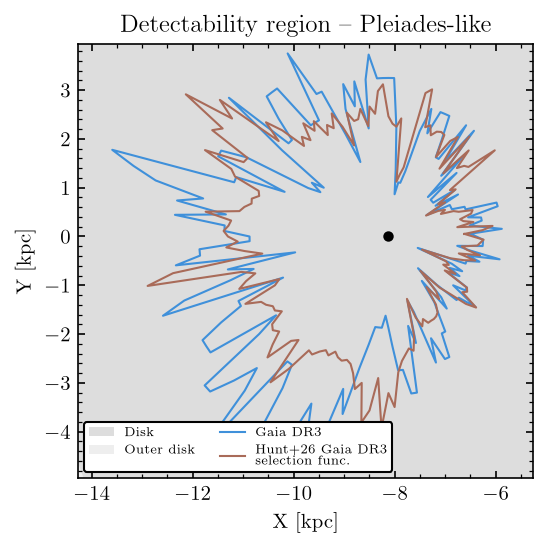

In [9]:
make_detectability_plot(
    detectabilities,
    ("gaia_dr3", "gaia_dr3_empirical"),
    title=r"Detectability region -- Pleiades-like",
    savefig=plots.FIGS_PRES / "pleiades_detectability_dr3_simple.png",
    legend_cols=2,
    legend_loc="lower left",
    x_max=-5000,
    # hr24_completeness_mass=1000,
)

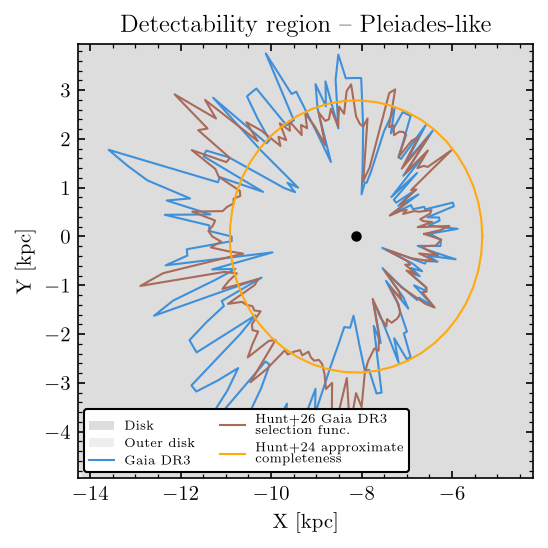

In [21]:
make_detectability_plot(
    detectabilities,
    ("gaia_dr3", "gaia_dr3_empirical"),
    title=r"Detectability region -- Pleiades-like",
    savefig=plots.FIGS_PRES / "pleiades_detectability_dr3.png",
    legend_cols=2,
    legend_loc="lower left",
    x_max=-4000,
    hr24_completeness_mass=1000,
)

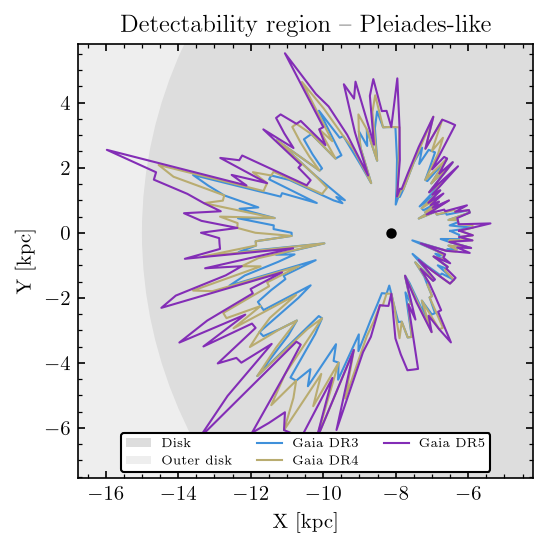

In [22]:
make_detectability_plot(
    detectabilities,
    ("gaia_dr3", "gaia_dr4", "gaia_dr5"),
    title="Detectability region -- Pleiades-like",
    savefig=plots.FIGS_PRES / "pleiades_detectability_gaia.png",
    legend_cols=3,
    x_max=-4000,
)

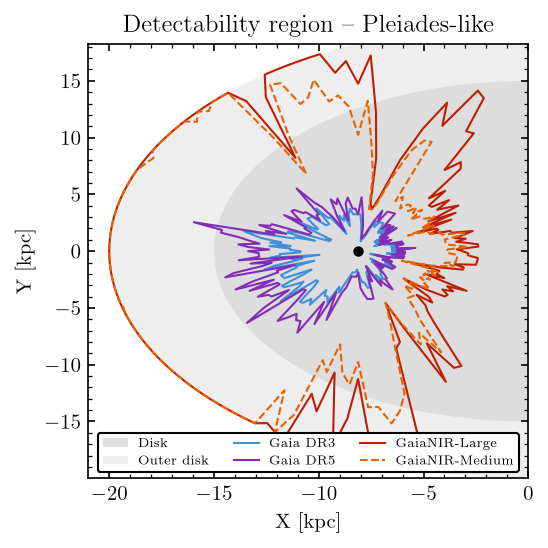

In [23]:
make_detectability_plot(
    detectabilities,
    ("gaia_dr3", "gaia_dr5", "gaianir-l", "gaianir-m"),
    title="Detectability region -- Pleiades-like",
    savefig=plots.FIGS_PRES / "pleiades_detectability_gaianir.png",
    legend_cols=3,
    x_max=0,
)

### Embedded cluster

In [24]:
detectabilities = calculate_detection_distances(detection_results, "embedded")

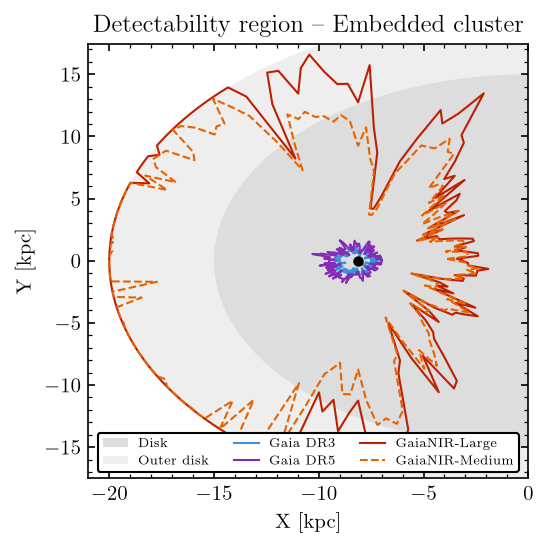

In [25]:
make_detectability_plot(
    detectabilities,
    ("gaia_dr3", "gaia_dr5", "gaianir-l", "gaianir-m"),
    title="Detectability region -- Embedded cluster",
    savefig=plots.FIGS_PRES / "embedded_detectability_gaianir.png",
    legend_cols=3,
    x_max=0,
)

### Berkeley 29

In [26]:
detectabilities = calculate_detection_distances(detection_results, "berkeley_29")

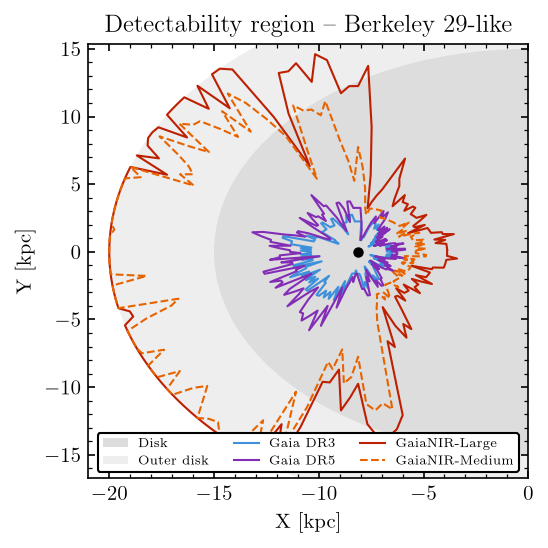

In [27]:
make_detectability_plot(
    detectabilities,
    ("gaia_dr3", "gaia_dr5", "gaianir-l", "gaianir-m"),
    title="Detectability region -- Berkeley 29-like",
    savefig=plots.FIGS_PRES / "berkeley_29_detectability_gaianir.png",
    legend_cols=3,
    x_max=0,
)

### IC 2602

In [28]:
detectabilities = calculate_detection_distances(detection_results, "ic_2602")

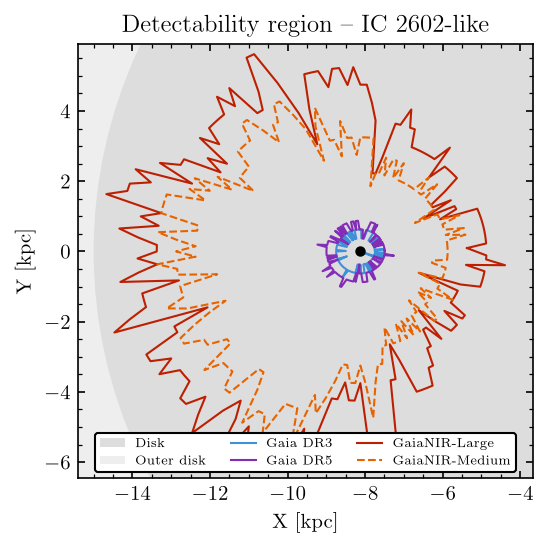

In [29]:
make_detectability_plot(
    detectabilities,
    ("gaia_dr3", "gaia_dr5", "gaianir-l", "gaianir-m"),
    title="Detectability region -- IC 2602-like",
    savefig=plots.FIGS_PRES / "ic_2602_detectability_gaianir.png",
    legend_cols=3,
    x_max=-3500,
)